In [8]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [9]:
# Load the fitness dataset
df = pd.read_csv(r'D:\ML\Datasets\fitness_dataset_clean_types_dirty_values.csv')
print('Shape:', df.shape)
df.head()

Shape: (100, 11)


,User_ID,Age,Gender,Daily_Steps,Workout_Hours,Diet_Type,Water_Intake_Liters,Sleep_Hours,Stress_Level,Health_Score,Fit_Status
0,401,27,Female,3306,1.4,Moderate,3.1,8.5,High,65.6,1
1,402,54,Female,14818,2.6,Moderate,3.2,8.2,Medium,68.6,1
2,403,33,Male,12754,0.5,Healthy,3.3,7.6,Medium,NaN,0
3,404,18,Female,120000,1.1,Unhealthy,1.1,5.5,Low,NaN,0
4,405,46,Male,5741,0.9,Moderate,3.0,5.8,Medium,97.6,1


In [10]:
tf = df.copy()

In [11]:
# Basic info and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   User_ID              100 non-null    int64  
 1   Age                  100 non-null    int64  
 2   Gender               100 non-null    object 
 3   Daily_Steps          100 non-null    int64  
 4   Workout_Hours        90 non-null     float64
 5   Diet_Type            100 non-null    object 
 6   Water_Intake_Liters  90 non-null     float64
 7   Sleep_Hours          90 non-null     float64
 8   Stress_Level         100 non-null    object 
 9   Health_Score         90 non-null     float64
 10  Fit_Status           100 non-null    int64  
dtypes: float64(4), int64(4), object(3)
memory usage: 8.7+ KB


In [12]:
# Statistical summary
df.describe()

,User_ID,Age,Daily_Steps,Workout_Hours,Water_Intake_Liters,Sleep_Hours,Health_Score,Fit_Status
count,100.000000,100.000000,100.000000,90.000000,90.000000,90.000000,90.000000,100.00
mean,450.500000,38.160000,10657.530000,1.473333,2.562222,6.321111,65.782222,0.55
std,29.011492,10.495521,12079.925096,1.401348,0.871339,2.021430,23.447204,0.50
min,401.000000,18.000000,1575.000000,0.000000,1.000000,4.000000,31.600000,0.00
25%,425.750000,30.000000,5879.750000,0.725000,1.800000,4.625000,46.000000,0.00
50%,450.500000,38.000000,9280.000000,1.200000,2.700000,6.000000,66.000000,1.00
75%,475.250000,46.250000,13298.000000,2.175000,3.375000,7.850000,81.975000,1.00
max,500.000000,58.000000,120000.000000,12.000000,3.900000,18.000000,180.000000,1.00


In [13]:
# Check null counts before treatment
print('Null values before treatment:')
print(df.isnull().sum())

Null values before treatment:
User_ID                 0
Age                     0
Gender                  0
Daily_Steps             0
Workout_Hours          10
Diet_Type               0
Water_Intake_Liters    10
Sleep_Hours            10
Stress_Level            0
Health_Score           10
Fit_Status              0
dtype: int64


In [14]:
# Fill numerical columns: skewed → median, normal → mean
# Fill categorical columns: mode

for col in df.columns:
    if df[col].isnull().sum() == 0:
        continue
    if df[col].dtype == 'object':
        # Categorical → fill with mode
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        skewness = df[col].skew()
        if abs(skewness) > 1:
            # Highly skewed → use median
            df[col].fillna(df[col].median(), inplace=True)
        else:
            # Approximately normal → use mean
            df[col].fillna(df[col].mean(), inplace=True)

print('Null values after treatment:')
print(df.isnull().sum())

Null values after treatment:
User_ID                0
Age                    0
Gender                 0
Daily_Steps            0
Workout_Hours          0
Diet_Type              0
Water_Intake_Liters    0
Sleep_Hours            0
Stress_Level           0
Health_Score           0
Fit_Status             0
dtype: int64


C:\Users\lenovo\AppData\Local\Temp\ipykernel_20792\2068143834.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\lenovo\AppData\Local\Temp\ipykernel_20792\2068143834.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

In [15]:
tf.head()

,User_ID,Age,Gender,Daily_Steps,Workout_Hours,Diet_Type,Water_Intake_Liters,Sleep_Hours,Stress_Level,Health_Score,Fit_Status
0,401,27,Female,3306,1.4,Moderate,3.1,8.5,High,65.6,1
1,402,54,Female,14818,2.6,Moderate,3.2,8.2,Medium,68.6,1
2,403,33,Male,12754,0.5,Healthy,3.3,7.6,Medium,NaN,0
3,404,18,Female,120000,1.1,Unhealthy,1.1,5.5,Low,NaN,0
4,405,46,Male,5741,0.9,Moderate,3.0,5.8,Medium,97.6,1


In [16]:
# Encode all object columns using LabelEncoder
le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns.tolist()
print('Categorical columns:', cat_cols)

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

df.head()

Categorical columns: ['Gender', 'Diet_Type', 'Stress_Level']


,User_ID,Age,Gender,Daily_Steps,Workout_Hours,Diet_Type,Water_Intake_Liters,Sleep_Hours,Stress_Level,Health_Score,Fit_Status
0,401,27,0,3306,1.4,1,3.1,8.5,0,65.6,1
1,402,54,0,14818,2.6,1,3.2,8.2,2,68.6,1
2,403,33,1,12754,0.5,0,3.3,7.6,2,66.0,0
3,404,18,0,120000,1.1,2,1.1,5.5,1,66.0,0
4,405,46,1,5741,0.9,1,3.0,5.8,2,97.6,1


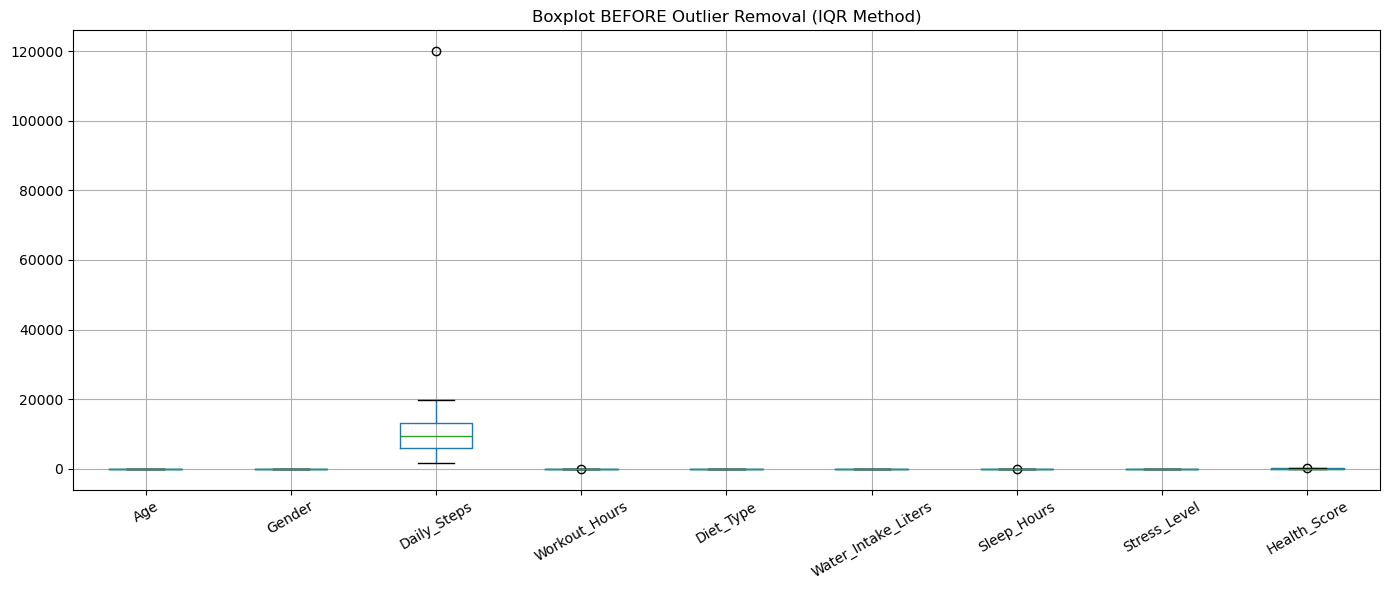

In [17]:
# Select numeric columns (excluding target and ID)
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c not in ['User_ID', 'Fit_Status']]

# ---- BEFORE Boxplot ----
plt.figure(figsize=(14, 6))
df[num_cols].boxplot(rot=30)
plt.title('Boxplot BEFORE Outlier Removal (IQR Method)')
plt.tight_layout()
plt.show()

In [18]:
# Apply IQR method to remove outliers from numeric columns
print('Rows before outlier removal:', len(df))

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]

print('Rows after outlier removal:', len(df))

Rows before outlier removal: 100
Rows after outlier removal: 96


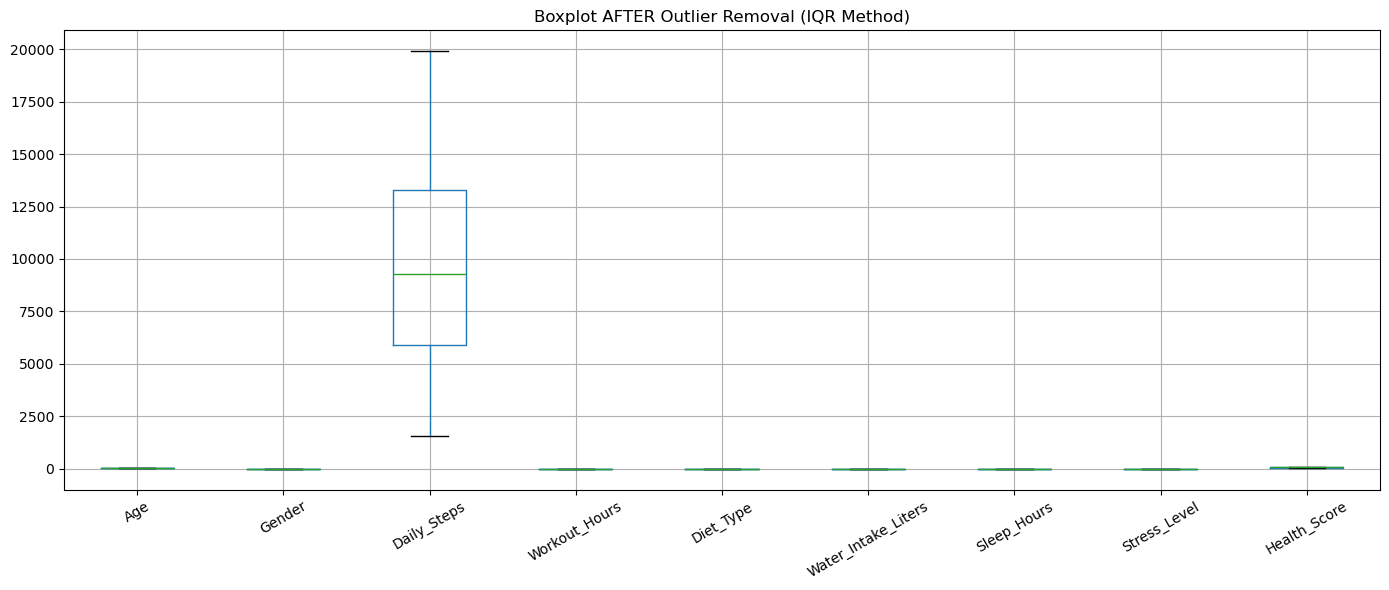

In [19]:
# ---- AFTER Boxplot ----
plt.figure(figsize=(14, 6))
df[num_cols].boxplot(rot=30)
plt.title('Boxplot AFTER Outlier Removal (IQR Method)')
plt.tight_layout()
plt.show()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_20792\69144258.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Fit_Status', data=df, palette='Set2')


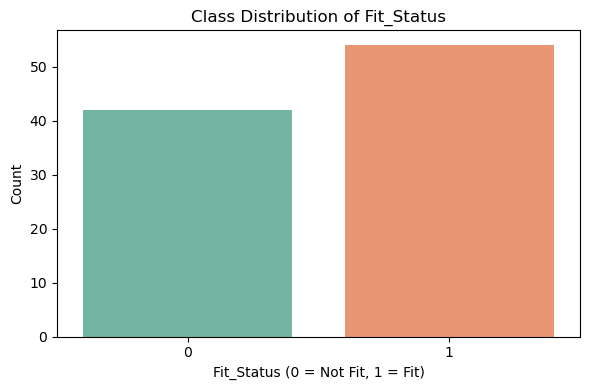

In [20]:
# --- Visualization 1: Target class distribution (Countplot) ---
plt.figure(figsize=(6, 4))
sns.countplot(x='Fit_Status', data=df, palette='Set2')
plt.title('Class Distribution of Fit_Status')
plt.xlabel('Fit_Status (0 = Not Fit, 1 = Fit)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [21]:
# Define features (X) and target (y)
X = df.drop(columns=['User_ID', 'Fit_Status'])
y = df['Fit_Status']

# Split into train and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train size:', X_train.shape)
print('Test size :', X_test.shape)

Train size: (76, 9)
Test size : (20, 9)


In [22]:
# Train Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

c:\Users\lenovo\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, random_state=42)

In [23]:
# Predictions on test set
y_pred = model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc:.4f}')



Accuracy: 0.9500


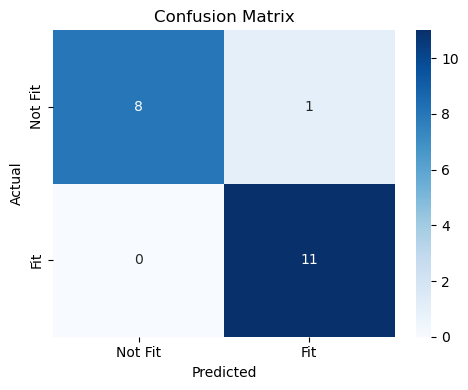

In [24]:
# Confusion Matrix heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fit', 'Fit'],
            yticklabels=['Not Fit', 'Fit'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()